# 03 Exploratory Analysis

Purpose: explore relationships between income, GDP, housing pressure, population growth, and innovation across 20 cities × 5 years.

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Load processed data (cleaned panel + scores)
panel = pd.read_csv(ROOT / 'data' / 'raw' / 'city_panel.csv')
scores = pd.read_csv(ROOT / 'data' / 'processed' / 'ueoi_scores.csv')
print(f'Panel: {panel.shape}')
print(f'Scores: {scores.shape}')

Panel: (100, 13)
Scores: (100, 9)


## 1. Distribution Overview

How are the core metrics distributed across the 100 city-year observations?

**How to read the x-axes**
- **GDP / Income:** yuan per person per year
- **Population growth:** year-on-year change in **percent** (not decimal)
- **R&D:** 100M yuan (亿)
- **Housing pressure:** `house_price / disposable_income` as **percent**; 19 cities use the NBS price index (~100), Suzhou uses yuan/sqm (right-tail outliers)

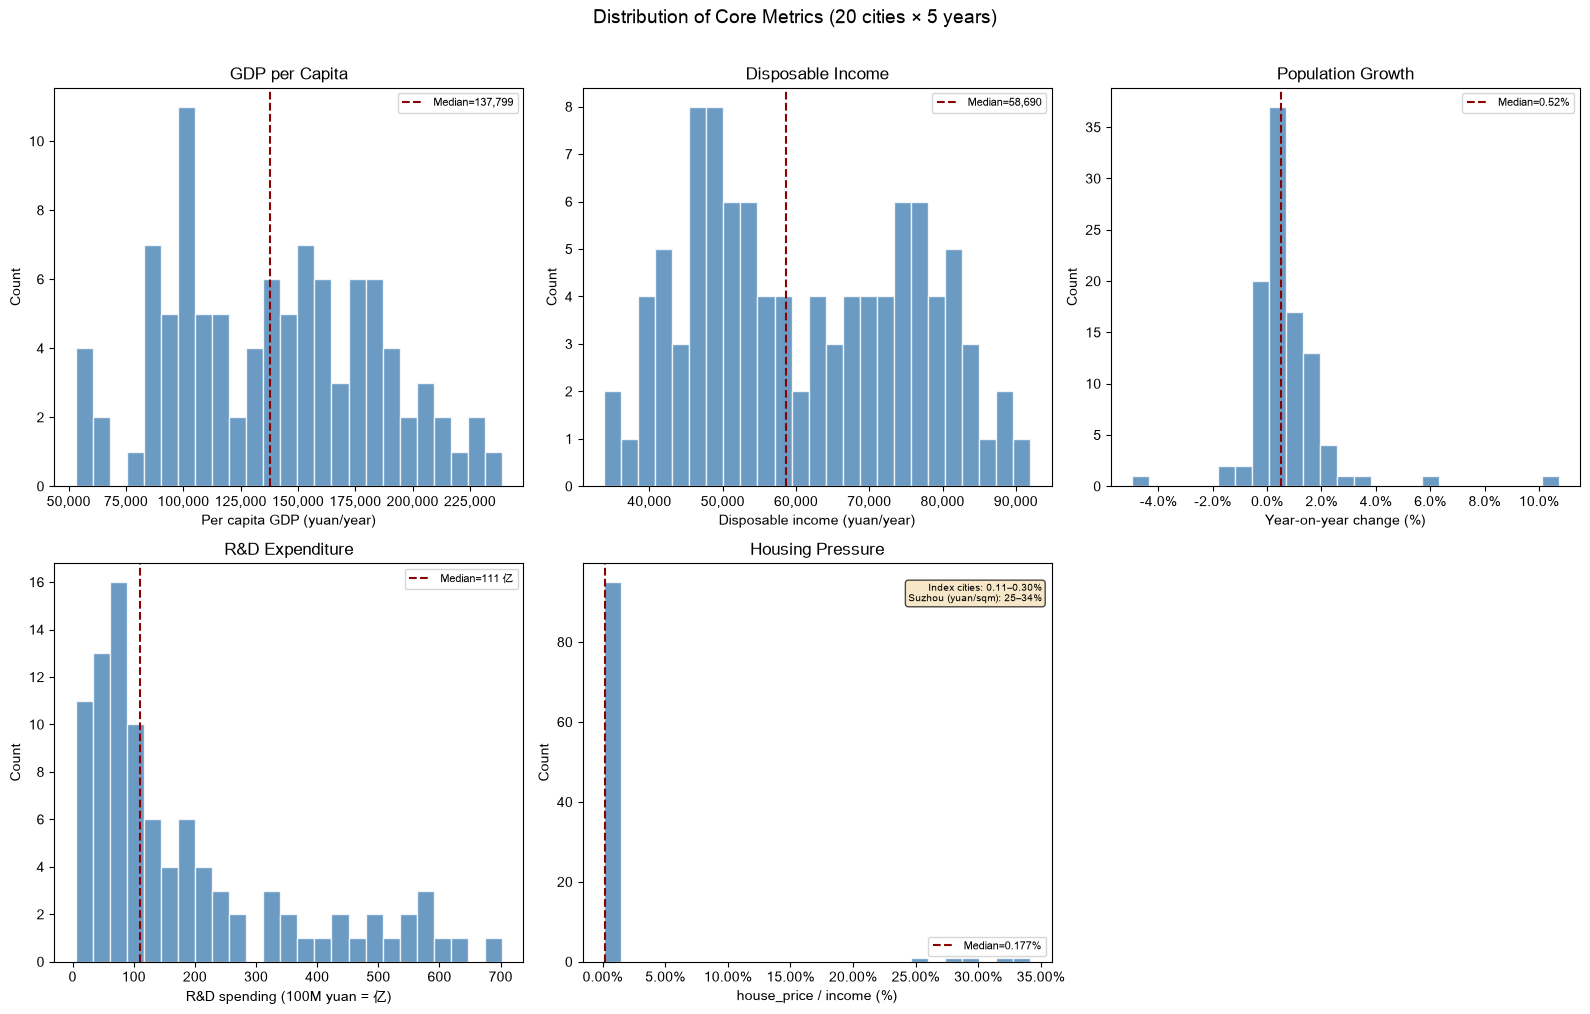

In [5]:
from matplotlib.ticker import FuncFormatter

plot_specs = [
    {
        'metric': 'gdp_per_capita',
        'title': 'GDP per Capita',
        'xlabel': 'Per capita GDP (yuan/year)',
        'transform': None,
        'median_label': lambda v: f'Median={v:,.0f}',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:,.0f}'),
    },
    {
        'metric': 'disposable_income',
        'title': 'Disposable Income',
        'xlabel': 'Disposable income (yuan/year)',
        'transform': None,
        'median_label': lambda v: f'Median={v:,.0f}',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:,.0f}'),
    },
    {
        'metric': 'population_growth',
        'title': 'Population Growth',
        'xlabel': 'Year-on-year change (%)',
        'transform': lambda s: s * 100,
        'median_label': lambda v: f'Median={v:.2f}%',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:.1f}%'),
    },
    {
        'metric': 'innovation_index',
        'title': 'R&D Expenditure',
        'xlabel': 'R&D spending (100M yuan = 亿)',
        'transform': None,
        'median_label': lambda v: f'Median={v:.0f} 亿',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:.0f}'),
    },
    {
        'metric': 'housing_burden',
        'title': 'Housing Pressure',
        'xlabel': 'house_price / income (%)',
        'transform': lambda s: s * 100,
        'median_label': lambda v: f'Median={v:.3f}%',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:.2f}%'),
    },
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, spec in enumerate(plot_specs):
    data = panel[spec['metric']].dropna()
    plot_data = spec['transform'](data) if spec['transform'] else data
    median = plot_data.median()

    ax = axes[i]
    ax.hist(plot_data, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(median, color='darkred', linestyle='--', label=spec['median_label'](median))
    ax.set_title(spec['title'])
    ax.set_xlabel(spec['xlabel'])
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(spec['x_formatter'])
    ax.legend(fontsize=8)

    if spec['metric'] == 'housing_burden':
        index_cities = panel.loc[panel['city'] != 'Suzhou', 'housing_burden'].dropna() * 100
        suzhou = panel.loc[panel['city'] == 'Suzhou', 'housing_burden'].dropna() * 100
        ax.text(
            0.98, 0.95,
            f'Index cities: {index_cities.min():.2f}–{index_cities.max():.2f}%\n'
            f'Suzhou (yuan/sqm): {suzhou.min():.0f}–{suzhou.max():.0f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
        )

axes[5].axis('off')
plt.suptitle('Distribution of Core Metrics (20 cities × 5 years)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Correlation Matrix

How do the five UEOI components correlate with each other?

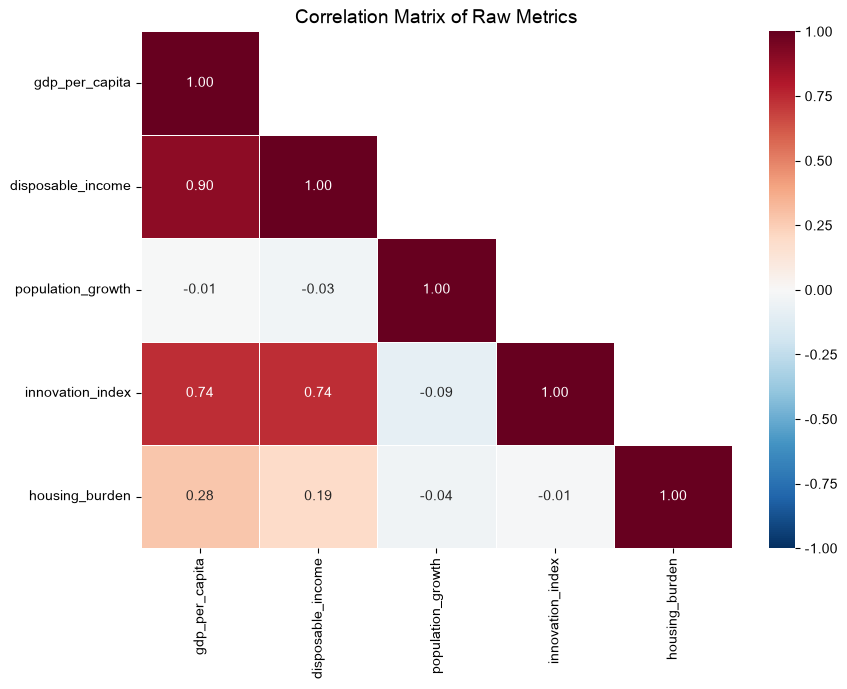

Key correlations:
  GDP p.c. ↔ Disposable Income: 0.90
  GDP p.c. ↔ Innovation: 0.74
  Disposable Income ↔ Housing Burden: 0.19


In [6]:
corr_fields = ['gdp_per_capita', 'disposable_income', 'population_growth', 'innovation_index', 'housing_burden']
corr = panel[corr_fields].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, linewidths=0.5, ax=ax,
            xticklabels=corr_fields, yticklabels=corr_fields)
ax.set_title('Correlation Matrix of Raw Metrics', fontsize=14)
plt.tight_layout()
plt.show()

print('Key correlations:')
print(f'  GDP p.c. ↔ Disposable Income: {corr.loc["gdp_per_capita","disposable_income"]:.2f}')
print(f'  GDP p.c. ↔ Innovation: {corr.loc["gdp_per_capita","innovation_index"]:.2f}')
print(f'  Disposable Income ↔ Housing Burden: {corr.loc["disposable_income","housing_burden"]:.2f}')

## 3. Time Trends by City Tier

How do metrics evolve over 2021–2025 by city tier?

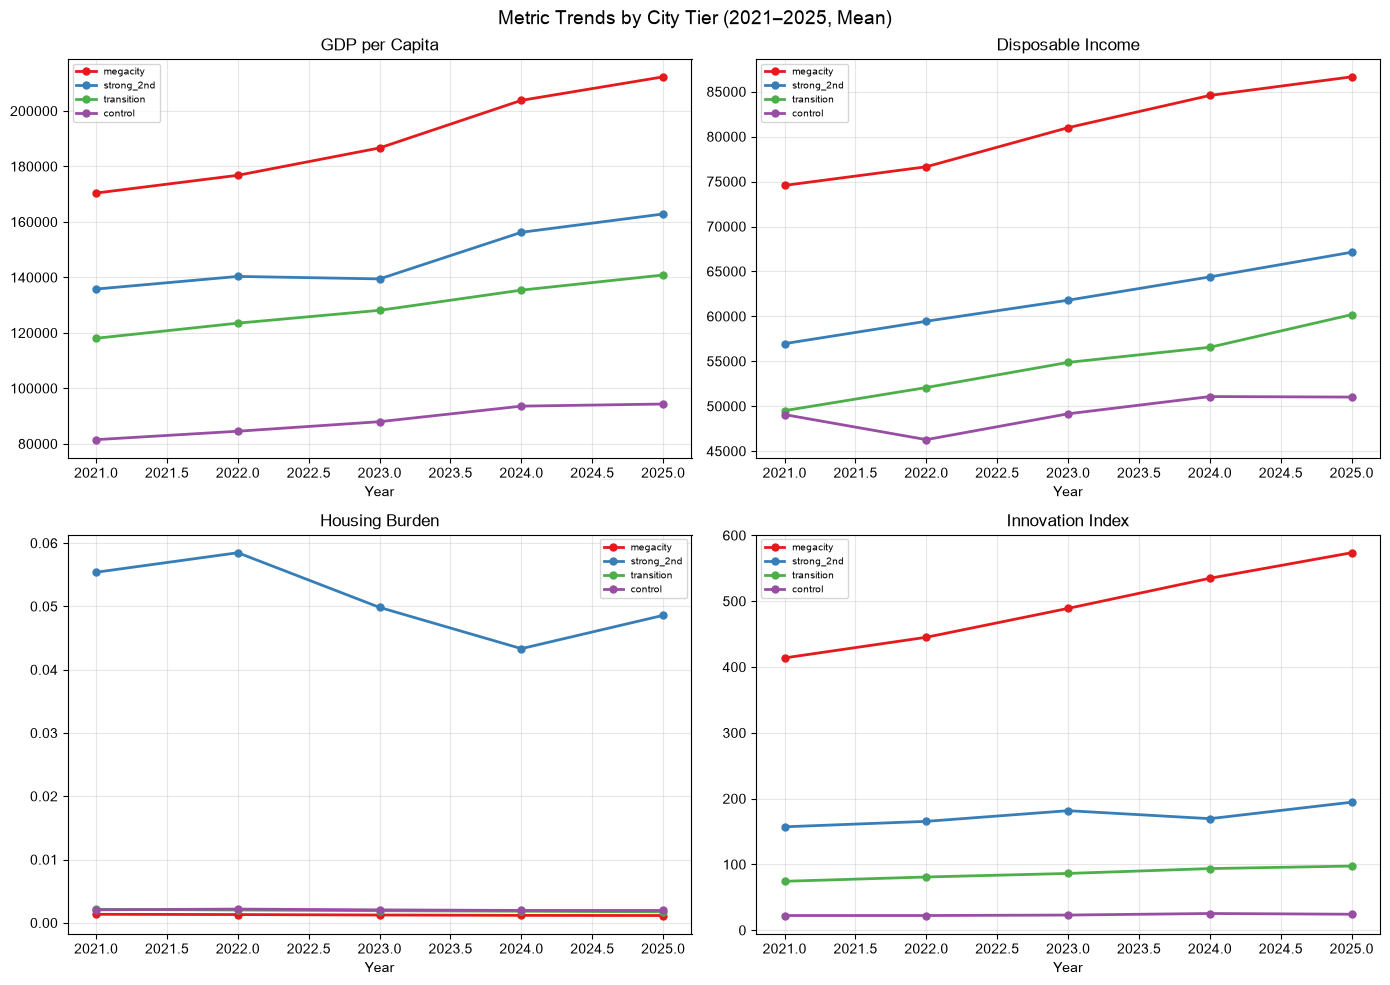

In [7]:
CITY_TIERS = {
    'megacity': ['Beijing', 'Shanghai', 'Shenzhen', 'Guangzhou'],
    'strong_2nd': ['Hangzhou', 'Nanjing', 'Suzhou', 'Chengdu', 'Wuhan', "Xi'an"],
    'transition': ['Hefei', 'Changsha', 'Qingdao', 'Xiamen', 'Zhengzhou', 'Chongqing'],
    'control': ['Harbin', 'Shenyang', 'Kunming', 'Nanchang'],
}
tier_map = {city: t for t, cities in CITY_TIERS.items() for city in cities}
panel_aug = panel.copy()
panel_aug['tier'] = panel_aug['city'].map(tier_map)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_metrics = ['gdp_per_capita', 'disposable_income', 'housing_burden', 'innovation_index']
plot_labels = ['GDP per Capita', 'Disposable Income', 'Housing Burden', 'Innovation Index']
colors = {'megacity': '#e41a1c', 'strong_2nd': '#377eb8', 'transition': '#4daf4a', 'control': '#984ea3'}

for i, (metric, label) in enumerate(zip(plot_metrics, plot_labels)):
    ax = axes[i // 2, i % 2]
    for tier, color in colors.items():
        tier_data = panel_aug[panel_aug['tier'] == tier].groupby('year')[metric].mean()
        ax.plot(tier_data.index, tier_data.values, 'o-', color=color, label=tier, linewidth=2, markersize=5)
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Metric Trends by City Tier (2021–2025, Mean)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Income vs Housing Burden

The central trade-off of this index: high-income cities tend to have higher housing costs.

In [ ]:
latest = panel[panel['year'] == panel['year'].max()]
latest_aug = latest.copy()
latest_aug['tier'] = latest_aug['city'].map(tier_map)

fig, ax = plt.subplots(figsize=(10, 7))
for tier, color in colors.items():
    subset = latest_aug[latest_aug['tier'] == tier]
    ax.scatter(subset['housing_burden'], subset['disposable_income'],
              c=color, label=tier, s=100, edgecolors='black', linewidth=0.5, zorder=5)
    for _, row in subset.iterrows():
        ax.annotate(row['city'], (row['housing_burden'], row['disposable_income']),
                   fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('Housing Burden (house_price / disposable_income)')
ax.set_ylabel('Disposable Income (yuan/year)')
ax.set_title(f'Income vs Housing Burden ({latest["year"].iloc[0]:.0f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation
r = latest['housing_burden'].corr(latest['disposable_income'])
print(f'Correlation (housing_burden ↔ income): r = {r:.3f}')

## 5. GDP vs Innovation

Does higher GDP per capita correlate with higher innovation spending?

In [ ]:
all_years = panel.dropna(subset=['gdp_per_capita', 'innovation_index'])

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(all_years['gdp_per_capita'], all_years['innovation_index'],
                     c=all_years['year'], cmap='viridis', s=60, alpha=0.7, edgecolors='white')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year')

# Label top-5 and bottom-5
top5_idx = all_years.nlargest(5, 'gdp_per_capita').index
for idx in top5_idx:
    row = all_years.loc[idx]
    ax.annotate(f"{row['city']} {int(row['year'])}", 
               (row['gdp_per_capita'], row['innovation_index']),
               fontsize=7, alpha=0.8)

ax.set_xlabel('GDP per Capita (yuan)')
ax.set_ylabel('Innovation Index (100M yuan S&T expenditure)')
ax.set_title('GDP per Capita vs Innovation Spending (2021–2025)')
ax.grid(True, alpha=0.3)

r2 = all_years['gdp_per_capita'].corr(all_years['innovation_index'])
ax.text(0.05, 0.95, f'r = {r2:.3f}', transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

## 6. Population Growth by City

Which cities are growing fastest?

In [ ]:
pop_growth = panel.pivot_table(index='city', columns='year', values='population_growth')
pop_growth['mean_5y'] = pop_growth.mean(axis=1)
pop_growth = pop_growth.sort_values('mean_5y', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pop_growth.drop(columns='mean_5y'), annot=True, fmt='.1%', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Population Growth Rate'})
ax.set_title('Population Growth Rate by City × Year')
plt.tight_layout()
plt.show()

## 7. UEOI Score Distribution

Final index distribution across all city-years.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
valid_scores = scores['ueoi_score'].dropna()
axes[0].hist(valid_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(valid_scores.median(), color='darkred', linestyle='--', label=f'Median={valid_scores.median():.1f}')
axes[0].set_xlabel('UEOI Score')
axes[0].set_ylabel('Count')
axes[0].set_title('UEOI Score Distribution')
axes[0].legend()

# Box plot by year
scores.boxplot(column='ueoi_score', by='year', ax=axes[1])
axes[1].set_title('UEOI Score by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('UEOI Score')
plt.suptitle('')
plt.tight_layout()
plt.show()